In [1]:
import numpy as np
import os

# Define the path to your input folder
data_path = '../input/generated'  # Replace 'your-dataset-folder' with your actual folder name

# Load the combined images and labels
combined_images = np.load(os.path.join(data_path, 'combined_images.npy'))
combined_labels = np.load(os.path.join(data_path, 'combined_labels.npy'))

print(f"Shape of combined images: {combined_images.shape}")
print(f"Shape of combined labels: {combined_labels.shape}")


Shape of combined images: (14818, 128, 128, 1)
Shape of combined labels: (14818,)


              precision    recall  f1-score   support

      Benign       0.86      0.99      0.92      1341
   Malignant       0.99      0.87      0.93      1623

    accuracy                           0.93      2964
   macro avg       0.93      0.93      0.93      2964
weighted avg       0.93      0.93      0.93      2964



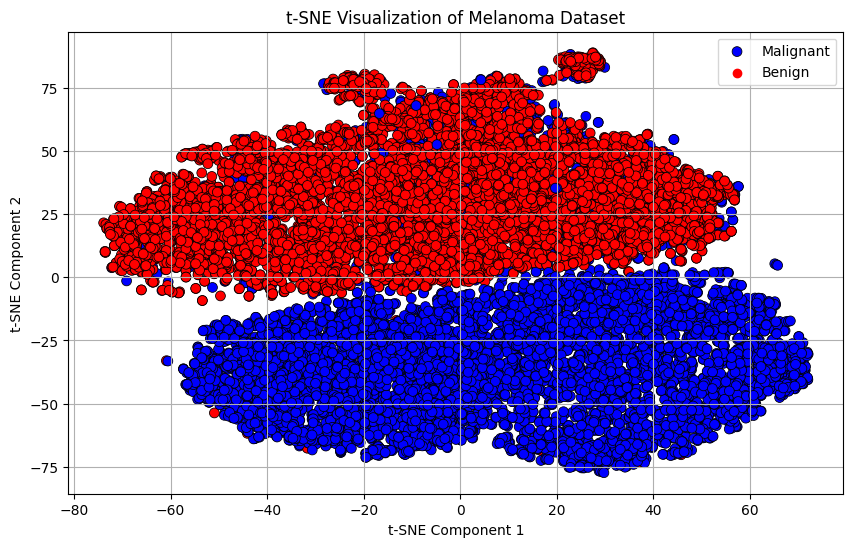

In [3]:
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Train SVM on Full Feature Space (Flattened Images)
X = combined_images.reshape(len(combined_images), -1)  # Flattened images
y = combined_labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

svm_model = SVC(kernel='rbf', gamma='scale')
svm_model.fit(X_train, y_train)

# Predictions and classification report
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

# Step 2: t-SNE Visualization
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

# Plot the t-SNE transformed data with decision boundary
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette=['red', 'blue'], edgecolor='k', s=50)
plt.title('t-SNE Visualization of Melanoma Dataset')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(['Malignant', 'Benign'])
plt.grid()
plt.show()


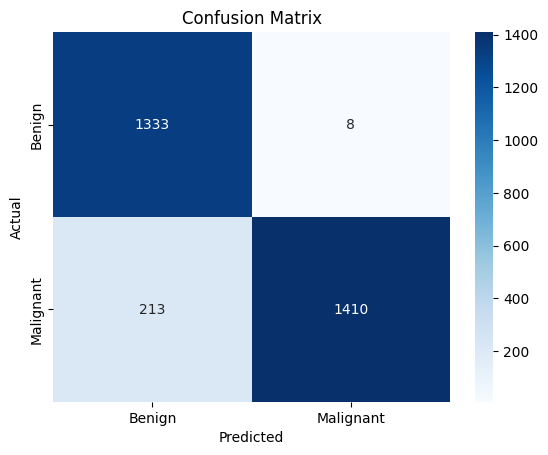

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [5]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


              precision    recall  f1-score   support

      Benign       0.86      0.99      0.92      1341
   Malignant       0.99      0.87      0.93      1623

    accuracy                           0.93      2964
   macro avg       0.93      0.93      0.93      2964
weighted avg       0.93      0.93      0.93      2964



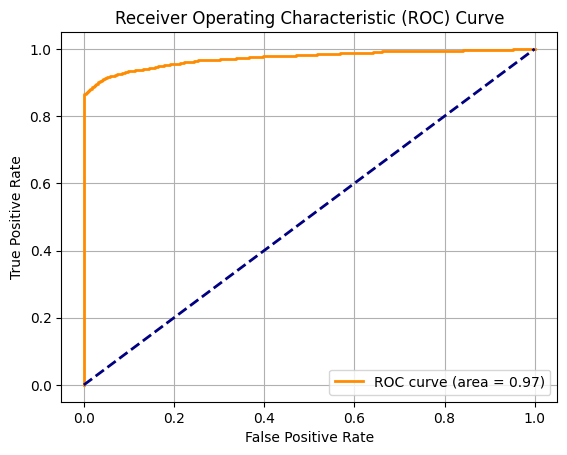

In [6]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = svm_model.decision_function(X_test)  # Use decision_function for SVM
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()
